#Install Library

In [50]:
pip install Sastrawi

In [51]:
pip install transformers torch

#Import Library

In [52]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import nltk
from transformers import pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import nltk
import nltk
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer
import string
import nltk
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
import nltk
from nltk.corpus import stopwords as nltk_stopwords

nltk.download('punkt')
nltk.download('stopwords')

stopword_id = set(nltk_stopwords.words('indonesian'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#Read Data

In [53]:
df = pd.read_excel('https://raw.github.com/dewitrilestari/Portofolio/main/Sentimen/Scraping/pelemahan%20rupiah.xlsx')

In [54]:
df

,text
0,hallo warga sipil sekalian semoga ini menjelas...
1,Rupiah melemah TKI bahagia
2,"Wkwkw nyari data pembandingnya cuma yg bagus2,..."
3,Barang aman barang tambung habis d vili sama a...
4,orang desa gk pake dolar kok pada bingung 😂
...,...
9922,first
9923,gercep
9924,❤
9925,pertama


#EDA

##Jumlah Data

In [55]:
df.shape

(9927, 1)

##Tipe Data

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9927 entries, 0 to 9926
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    9927 non-null   object
dtypes: object(1)
memory usage: 77.7+ KB


##Statistika Dasar

In [57]:
df.describe()

,text
count,9927
unique,9414
top,saatnya GANTI PRESIDEN!!!
freq,17


##Missing Values

In [58]:
df.isnull().sum()

,0
text,0


##Duplicate Data

In [59]:
df.duplicated().sum()

np.int64(513)

In [60]:
df.drop_duplicates(inplace=True)

##Distribusi Data

In [61]:
# Menghitung jumlah kata per baris data
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Menampilkan statistik deskriptif (mean, median/50%, min, max, std)
print(df['word_count'].describe())

count    9414.000000
mean       19.503293
std        32.700300
min         1.000000
25%         6.000000
50%        11.000000
75%        22.000000
max      1246.000000
Name: word_count, dtype: float64


##Visualisasi

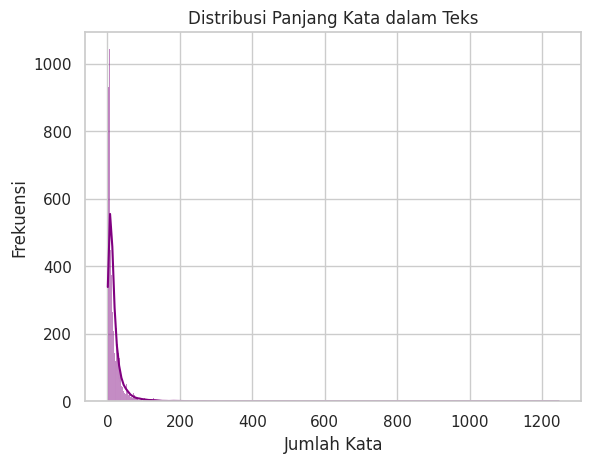

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['word_count'], kde=True, color='purple')
plt.title('Distribusi Panjang Kata dalam Teks')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.show()

#Preprocessing

##Case Folding

In [63]:
def case_folding(text):
    if isinstance(text, str):
      lowercase_text = text.lower()
      return lowercase_text
    else:
        return text

df['case_folding'] = df['text'].apply(case_folding)
df.head(10)

,text,word_count,case_folding
0,hallo warga sipil sekalian semoga ini menjelas...,9,hallo warga sipil sekalian semoga ini menjelas...
1,Rupiah melemah TKI bahagia,4,rupiah melemah tki bahagia
2,"Wkwkw nyari data pembandingnya cuma yg bagus2,...",14,"wkwkw nyari data pembandingnya cuma yg bagus2,..."
3,Barang aman barang tambung habis d vili sama a...,10,barang aman barang tambung habis d vili sama a...
4,orang desa gk pake dolar kok pada bingung 😂,9,orang desa gk pake dolar kok pada bingung 😂
5,Hilang kepercayaan investor asing. Itu penyeba...,7,hilang kepercayaan investor asing. itu penyeba...
6,Bang kite kan sipil jadi kalau ada singkatan s...,23,bang kite kan sipil jadi kalau ada singkatan s...
7,Keren bang,2,keren bang
8,Maka jgn ganggu pegawai BI & KEMENKEU lg sibuk...,28,maka jgn ganggu pegawai bi & kemenkeu lg sibuk...
9,Menurutku seumpama MBG ga ada pun dan belanja ...,28,menurutku seumpama mbg ga ada pun dan belanja ...


##Cleaning

In [64]:
def cleaning(text):

    text = str(text)

    # hapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # hapus mention
    text = re.sub(r'@\w+', '', text)

    # hapus hashtag
    text = re.sub(r'#\w+', '', text)

    # ganti titik menjadi spasi
    text = text.replace('.', ' ')

    # ganti underscore
    text = text.replace('_', ' ')

    # hapus angka
    text = re.sub(r'\d+', '', text)

    # hapus emoji
    text = re.sub(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+",
        '',
        text,
        flags=re.UNICODE
    )

    # hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # hapus karakter selain huruf
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['cleaning'] = df['case_folding'].apply(cleaning)

In [65]:
df

,text,word_count,case_folding,cleaning
0,hallo warga sipil sekalian semoga ini menjelas...,9,hallo warga sipil sekalian semoga ini menjelas...,hallo warga sipil sekalian semoga ini menjelas...
1,Rupiah melemah TKI bahagia,4,rupiah melemah tki bahagia,rupiah melemah tki bahagia
2,"Wkwkw nyari data pembandingnya cuma yg bagus2,...",14,"wkwkw nyari data pembandingnya cuma yg bagus2,...",wkwkw nyari data pembandingnya cuma yg bagus g...
3,Barang aman barang tambung habis d vili sama a...,10,barang aman barang tambung habis d vili sama a...,barang aman barang tambung habis d vili sama a...
4,orang desa gk pake dolar kok pada bingung 😂,9,orang desa gk pake dolar kok pada bingung 😂,orang desa gk pake dolar kok pada bingung
...,...,...,...,...
9920,Zimbabwe gundulmu itu. Makanya klo nonton baha...,13,zimbabwe gundulmu itu. makanya klo nonton baha...,zimbabwe gundulmu itu makanya klo nonton bahas...
9921,🎉,1,🎉,
9922,first,1,first,first
9923,gercep,1,gercep,gercep


###Hapus NaN

In [66]:
# Menghitung baris yang benar-benar kosong ""
jumlah_kosong = (df['cleaning'] == "").sum()

print(f"Jumlah komentar yang menjadi kosong: {jumlah_kosong}")

Jumlah komentar yang menjadi kosong: 73


In [67]:
# Ubah string kosong "" menjadi NaN agar bisa dideteksi dropna
df["cleaning"] = df["cleaning"].replace("", np.nan)

In [68]:
# Menghapus baris yang kolom 'cleaning'-nya bernilai NaN
df = df.dropna(subset=['cleaning'])

# Jangan lupa reset index agar nomor barisnya berurutan kembali
df = df.reset_index(drop=True)

#Tokenize

In [69]:
def tokenize(text):
    tokens = text.split()
    return tokens

df['tokenize'] = df['cleaning'].apply(tokenize)
df.head(10)

,text,word_count,case_folding,cleaning,tokenize
0,hallo warga sipil sekalian semoga ini menjelas...,9,hallo warga sipil sekalian semoga ini menjelas...,hallo warga sipil sekalian semoga ini menjelas...,"[hallo, warga, sipil, sekalian, semoga, ini, m..."
1,Rupiah melemah TKI bahagia,4,rupiah melemah tki bahagia,rupiah melemah tki bahagia,"[rupiah, melemah, tki, bahagia]"
2,"Wkwkw nyari data pembandingnya cuma yg bagus2,...",14,"wkwkw nyari data pembandingnya cuma yg bagus2,...",wkwkw nyari data pembandingnya cuma yg bagus g...,"[wkwkw, nyari, data, pembandingnya, cuma, yg, ..."
3,Barang aman barang tambung habis d vili sama a...,10,barang aman barang tambung habis d vili sama a...,barang aman barang tambung habis d vili sama a...,"[barang, aman, barang, tambung, habis, d, vili..."
4,orang desa gk pake dolar kok pada bingung 😂,9,orang desa gk pake dolar kok pada bingung 😂,orang desa gk pake dolar kok pada bingung,"[orang, desa, gk, pake, dolar, kok, pada, bing..."
5,Hilang kepercayaan investor asing. Itu penyeba...,7,hilang kepercayaan investor asing. itu penyeba...,hilang kepercayaan investor asing itu penyebab...,"[hilang, kepercayaan, investor, asing, itu, pe..."
6,Bang kite kan sipil jadi kalau ada singkatan s...,23,bang kite kan sipil jadi kalau ada singkatan s...,bang kite kan sipil jadi kalau ada singkatan s...,"[bang, kite, kan, sipil, jadi, kalau, ada, sin..."
7,Keren bang,2,keren bang,keren bang,"[keren, bang]"
8,Maka jgn ganggu pegawai BI & KEMENKEU lg sibuk...,28,maka jgn ganggu pegawai bi & kemenkeu lg sibuk...,maka jgn ganggu pegawai bi kemenkeu lg sibuk k...,"[maka, jgn, ganggu, pegawai, bi, kemenkeu, lg,..."
9,Menurutku seumpama MBG ga ada pun dan belanja ...,28,menurutku seumpama mbg ga ada pun dan belanja ...,menurutku seumpama mbg ga ada pun dan belanja ...,"[menurutku, seumpama, mbg, ga, ada, pun, dan, ..."


#Normalisasi Slang

In [71]:
slang_dict = {
    # KATA SLANG UTAMA & VARIASI TEKS
    'hallo': 'halo', 'tki': 'tenaga kerja indonesia', 'malaydesh': 'malaysia', 'tambung': 'tampung',
    'd': 'di', 'fer': 'fery', 'bumn': 'badan usaha milik negara', 'bumd': 'badan usaha milik daerah',
    'bal': 'balik', 'wawas': 'wawasan', 'msk': 'masuk', 'ku': 'aku',
    'mcm': 'macam', 'nii': 'ini', 'sbb': 'sebab', 'ituu': 'itu',
    'jangannnnn': 'jangan', 'dmn': 'dimana', 'sbg': 'sebagai', 'dtuntut': 'dituntut',
    'mreka': 'mereka', 'drmh': 'dirumah', 'sndr': 'sendiri', 'bgitu': 'begitu',
    'salusi': 'solusi', 'sll': 'selalu', 'oejabat': 'pejabat', 'boss': 'bos',
    'terimakasih': 'terima kasih', 'moga': 'semoga', 'sehattt': 'sehat', 'spt': 'seperti',
    'smula': 'semula', 'klopun': 'kalaupun', 'dturunin': 'diturunin', 'brarti': 'berarti',
    'jikaaaaa': 'jika', 'bgini': 'begini', 'bgmn': 'bagaimana', 'emng': 'memang',
    'banh': 'bang', 'siapp': 'siap', 'masalh': 'masalah', 'pgn': 'ingin',
    'ndak': 'tidak', 'makas': 'maka', 'asyiik': 'asyik', 'banyakkk': 'banyak',
    'make': 'pakai', 'wowo': 'prabowo', 'tariff': 'tarif', 'praktek': 'praktik',
    'jokowiiiiiiiiiiiiiiiiiiii': 'jokowi', 'mantabbb': 'bagus', 'nyetak': 'cetak', 'thdp': 'terhadap',
    'emg': 'memang', 'lbh': 'lebih', 'ane': 'saya', 'gblg': 'goblok',
    'wni': 'warga negara indonesia', 'makn': 'makan', 'jelassssss': 'jelas', 'sorosssssssss': 'soros',
    'guyumu': 'tawa', 'halahhh': 'halah', 'ayooo': 'ayo', 'pnjelasannya': 'jelas',
    'meledakkk': 'meledak', 'wo': 'prabowo', 'duh': 'aduh', 'dimna': 'dimana',
    'ngapain': 'mengapa', 'becus': 'benar', 'ketja': 'kerja', 'possitive': 'positive',
    'prrlu': 'perlu', 'jelasss': 'jelas', 'ora': 'tidak', 'guoblok': 'bodoh',
    'rb': 'ribu', 'ajah': 'aja', 'luh': 'kamu', 'sok sok': 'purapura',
    'haduhhhh': 'aduh', 'tar': 'nanti', 'mkn': 'makan', 'rupiah': 'rupiah',
    'fktor': 'faktor', 'kyak': 'seperti', 'rp': 'rupiah', 'mw': 'mau',
    'ceplokkk': 'ceplok', 'antre': 'antri', 'trun': 'turun', 'acu': 'aku',
    'skarang': 'sekarang', 'gausah': 'tidak perlu', 'anggar': 'anggaran', 'fufufafa': 'gibran',
    'faham': 'paham', 'pur': 'purbaya', 'loyo': 'lemah', 'bini': 'istri',
    'ngakak': 'tertawa', 'gt': 'begitu', 'aza': 'aja', 'tidk': 'tidak',
    'sotau': 'purapura tau', 'trus': 'terus', 'bowok': 'prabowo', 'stress': 'stress',
    'dolar': 'dollar', 'bae': 'aja', 'abg': 'abang', 'karna': 'karena',
    'lsg': 'langsung', 'yng': 'yang', 'intiny': 'inti', 'imba': 'imbas',
    'koplak': 'bodoh', 'hancurr': 'hancur', 'negera': 'negeri', 'benwran': 'benar',
    'bener': 'benar', 'kelasss': 'kelas', 'kek': 'seperti', 'busyettt': 'buset',
    'gaje': 'tidak jelas', 'yo': 'iya', 'wes': 'sudah', 'pinter': 'pintar',
    'sodraa': 'saudara', 'w': 'saya', 'mbgeeeeeeh': 'mbg', 'yoook': 'ayo',
    'elu': 'kamu', 'nyimak': 'simak', 'mantap': 'bagus', 'ngra': 'negara',
    'ajurrrrr': 'hancur', 'emberge': 'mbg', 'capee': 'lelah', 'gpp': 'tidak apa apa',
    'mu': 'kamu', 'ribet': 'rumit', 'oeduli': 'peduli', 'puyeng': 'pusing',
    'dengernya': 'dengar', 'denger': 'dengar', 'pls': 'tolong', 'gaa': 'tidak',
    'fryy': 'fry', 'nm': 'nama', 'embegehhh': 'mbg', 'tll': 'bodoh',
    'jadiin': 'jadi', 'besaaarrrr': 'besar', 'otw': 'on the way', 'mngkin': 'mungkin',
    'guoblokk': 'bodoh', 'ky': 'seperti', 'nyocot': 'banyak bicara', 'mumpung': 'selagi',
    'ilanh': 'hilang', 'btw': 'by the way', 'waw': 'wow', 'antekantek': 'kawan',
    'aseng': 'asing', 'pilihann': 'pilihan', 'pleciden': 'presiden', 'ai': 'aku',
    'bacot': 'banyak bicara', 'beres': 'selesai', 'mrs': 'miris', 'kdang': 'kadang',
    'soroz': 'soros', 'sorozz': 'soros', 'kampong': 'kampung', 'cz': 'karena',
    'lgii': 'lagi', 'hbis': 'habis', 'lawakannn': 'lawak', 'rkyta': 'rakyat',
    'u': 'you', 'n i c e': 'nice', 'truss': 'terus', 'anteek anteek': 'kawan',
    'aseeeng': 'asing', 'coz': 'karena', 'menwhile': 'meanwhile', 'kocak': 'lucu',
    'ngerti': 'erti', 'edan': 'gila', 'anjer': 'sialan', 'byajingan': 'sialan',
    'tai': 'sialan', 'goblok': 'bodoh', 'anj': 'sialan', 'taeeeee': 'sialan',
    'anjir': 'sialan', 'anjay': 'sialan', 'preeeettr': 'bohong', 'khontolll': 'sialan',
    'krismon': 'krisis moneter', 'belkang': 'belakang', 'mngkn': 'mungkin', 'ttg': 'tentang',
    'milu': 'pemilihan umum', 'niceee': 'nice', 'sby': 'susilo bambang yudhoyono', 'umr': 'upah minimum regional',
    'kasi': 'beri', 'dongo': 'bodoh', 'mft': 'my favorite thing', 'due': 'punya',
    'ngk': 'tidak', 'blng': 'bilang', 'rejim': 'rezim', 'jilatin': 'jilat',
    'hadeh': 'aduh', 'byar': 'bayar', 'gapapa': 'tidak apa apa', 'hancuuuur': 'hancur',
    'wowow': 'prabowo', 'plz': 'tolong', 'bergerakkkk': 'bergerak', 'yaman': 'zaman',
    'kee': 'ke', 'kayak': 'seperti', 'hudup': 'hidup', 'bjirr': 'sialan',
    'uanh': 'uang', 'ngaruh': 'pengaruh', 'bliaw': 'beliau', 'sumpa': 'sumpah',
    'nymp': 'sampai', 'bangg': 'bang', 'ngajak': 'ajak', 'kitaaaaaaaaa': 'kita',
    'cerdassssssss': 'cerdas', 'nyesel': 'sesal', 'ngebayangin': 'bayang', 'ape': 'apa',
    'mjd': 'menjadi', 'ndeso': 'desa', 'embege': 'mbg', 'ytta': 'yang tau tau aja',
    'kyanya': 'seperti', 'srmua': 'semua', 'matah': 'marah', 'terburukkkkk': 'terburuk',
    'kudu': 'harus', 'masukkkkkkkkkkkkkkkkkkkkkkkkkkk': 'masuk', 'engga': 'tidak', 'p': 'pak',
    'indodesh': 'indonesia', 'tuuuulll': 'betul', 'suwon': 'makasih', 'benernya': 'benar',
    'koment': 'komen', 'beginu': 'begini', 'dripada': 'daripada', 'jokowik': 'jokowi',
    'hokage': 'presiden', 'gilaa': 'gila', 'rill': 'nyata', 'blackbord': 'blackboard',
    'sok': 'berlagak', 'peminpin': 'pemimpin', 'emank': 'memang', 'perrrrrrrrrrrrrrrrrrrrrr': 'fer',
    'gasss': 'gas', 'kereeen': 'keren', 'gedeg': 'kesal', 'miriss': 'miris',
    'hadehhhhhh': 'aduh', 'km': 'kamu', 'najam': 'tajam', 'iyaa': 'iya',
    'mantab': 'bagus', 'brics': 'brazil rusia india china south africa', 'viralkannnn': 'viral', 'menkeu': 'menteri keuangan',
    'pkoknya': 'pokok', 'yukk': 'ayo', 'dll': 'dan lain lain', 'ntar': 'nanti',
    'truee': 'true', 'gtu': 'gitu', 'em be ge': 'mbg', 'tsb': 'tersebut',
    'dipake': 'pakai', 'sickkk': 'sick', 'netrall': 'netral', 'smua': 'semua',
    'taek': 'sialan', 'taik': 'sialan', 'sepertix': 'seperti', 'nugguin': 'tunggu',
    'vs': 'versus', 'iq': 'intelligence quotient', 'bangsyattttt': 'sialan', 'upp': 'up',
    'preketek': 'bohong', 'pakek': 'pakai', 'npd': 'narcissitic personality disorder', 'speakup': 'speak up',
    'pantesan': 'pantas', 'kacawww': 'kacau', 'intelektualistas': 'intelektualitas', 'jt': 'juta',
    'rungokno': 'dengar', 'spy': 'supaya', 'bgn': 'badan gizi nasional', 'burukk': 'buruk',
    'cepet': 'cepat', 'joran': 'besar', 'turunin': 'turun', 'kameramennnnnnnnn': 'kameramen',
    'bujer': 'buzzer', 'ajggg': 'sialan', 'trimakasih': 'terima kasih', 'ttep': 'tetap',
    'negeruku': 'negaraku', 'krasa': 'rasa', 'pk': 'pak', 'liat': 'lihat',
    'dng': 'dengan', 'trbaik': 'terbaik', 'yt': 'youtube', 'omo': 'astaga',
    'bet': 'banget', 'njing': 'sialan', 'teruussin': 'lanjut', 'wowok': 'prabowo',
    'kritiku': 'kritikus', 'goblk': 'bodoh', 'dlu': 'dulu', 'ngirit': 'irit',
    'fomo': 'takut tertinggal', 'gercep': 'gerak cepat', 'phk': 'pemutusan hubungan kerja',
    'first': 'pertama',

    # TYPO & SINGKATAN
    'skrng': 'sekarang', 'ngak': 'tidak', 'krna': 'karena', 'dlm': 'dalam',
    'lgi': 'lagi', 'hrs': 'harus', 'pd': 'pada', 'bnyak': 'banyak',
    'ancur': 'hancur', 'dikit': 'sedikit', 'mulu': 'saja', 'judol': 'judi online',
    'skrg': 'sekarang', 'knp': 'kenapa', 'dri': 'dari', 'ama': 'sama',
    'pas': 'saat', 'gede': 'besar', 'jaman': 'zaman', 'ri': 'republik indonesia',
    'tu': 'itu', 'komen': 'komentar', 'gara': 'gara gara',

    # ISTILAH EKONOMI, POLITIK & VARIASI BAHASA
    'bg': 'bang', 'bng': 'bang', 'jg': 'juga', 'sampe': 'sampai',
    'gitu': 'begitu', 'gini': 'begini', 'negri': 'negeri', 'dah': 'sudah',
    'cuman': 'cuma', 'lo': 'kamu', 'g': 'tidak', 't': 'triliun',
    'export': 'ekspor', 'invstor': 'investor', 'asng': 'asing', 'dlr': 'dolar',
    'nominalx': 'nominalnya', 'dgan': 'dengan', 'beza': 'beda', 'x': 'tidak',
    'bnr': 'benar', 'klian': 'kalian', 'gmn': 'gimana', 'plg': 'paling',
    'mmg': 'memang', 'tau': 'tahu', 'indo': 'indonesia', 'indon': 'indonesia',
    'msh': 'masih', 'ttp': 'tetap', 'htg': 'utang', 'utg': 'utang',
    'aj': 'saja', 'nyari': 'cari', 'klen': 'kalian', 'noh': 'itu',
    'tuh': 'itu', 'kite': 'kita', 'mengatasix': 'mengatasi', 'wkwk': '',
    'wkwkw': '',

    # TAMBAHAN KATA TUGAS & UTAL-UTIL
    'yg': 'yang', 'dg': 'dengan', 'dgn': 'dengan', 'utk': 'untuk',
    'krn': 'karena', 'dr': 'dari', 'trs': 'terus', 'bwt': 'buat',
    'byr': 'bayar', 'sm': 'sama', 'sdh': 'sudah', 'udh': 'sudah',
    'udah': 'sudah', 'udeh': 'sudah', 'blm': 'belum', 'jd': 'jadi',
    'jdi': 'jadi', 'bkn': 'bukan', 'hr': 'hari', 'hri': 'hari',
    'thn': 'tahun', 'bln': 'bulan', 'byk': 'banyak', 'bnyk': 'banyak',
    'sdkt': 'sedikit', 'mnrt': 'menurut', 'pdhl': 'padahal', 'bs': 'bisa',
    'bsa': 'bisa', 'aja': 'saja', 'doang': 'saja', 'cm': 'cuma',
    'cmn': 'cuma', 'tetep': 'tetap', 'lg': 'lagi', 'tlg': 'tolong',
    'lu': 'kamu', 'loe': 'kamu', 'lho': 'kamu', 'sy': 'saya',
    'sya': 'saya', 'gw': 'saya', 'gua': 'saya', 'gue': 'saya',
    'aq': 'aku', 'mrk': 'mereka', 'ank': 'anak', 'ortu': 'orang tua',
    'bpk': 'bapak', 'pak': 'bapak', 'bu': 'ibu', 'gk': 'tidak',
    'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'ngga': 'tidak',
    'enggak': 'tidak', 'tdk': 'tidak', 'jgn': 'jangan', 'jngn': 'jangan',
    'bgt': 'banget', 'bngt': 'banget', 'bnget': 'banget', 'dpt': 'dapat',
    'dapet': 'dapat', 'pke': 'pakai', 'pkai': 'pakai', 'pake': 'pakai',
    'org': 'orang', 'smoga': 'semoga', 'kyk': 'seperti', 'kyknya': 'sepertinya',
    'klu': 'kalau', 'kalo': 'kalau', 'klo': 'kalau', 'kl': 'kalau',
    'tp': 'tapi', 'tpi': 'tapi', 'mbg': 'makan bergizi gratis', 'rkyt': 'rakyat',
    'masyrkt': 'masyarakat', 'pemrintah': 'pemerintah', 'pmrintah': 'pemerintah', 'uu': 'undang undang',
    'bi': 'bank indonesia', 'kemenkeu': 'kementerian keuangan'
}

def normalize_slang(tokens):
    return [slang_dict[word] if word in slang_dict else word for word in tokens]

# Penerapan pada DataFrame
df['normalize'] = df['tokenize'].apply(normalize_slang)

##ReTokenize

In [72]:
def normalize_and_split_slang(tokens):
    new_tokens = []
    for word in tokens:
        if word in slang_dict:
            normalized_words = slang_dict[word].split()
            new_tokens.extend(normalized_words)
        else:
            new_tokens.append(word)
    return new_tokens

df['normalize'] = df['tokenize'].apply(normalize_and_split_slang)

In [73]:
df

,text,word_count,case_folding,cleaning,tokenize,normalize
0,hallo warga sipil sekalian semoga ini menjelas...,9,hallo warga sipil sekalian semoga ini menjelas...,hallo warga sipil sekalian semoga ini menjelas...,"[hallo, warga, sipil, sekalian, semoga, ini, m...","[halo, warga, sipil, sekalian, semoga, ini, me..."
1,Rupiah melemah TKI bahagia,4,rupiah melemah tki bahagia,rupiah melemah tki bahagia,"[rupiah, melemah, tki, bahagia]","[rupiah, melemah, tenaga, kerja, indonesia, ba..."
2,"Wkwkw nyari data pembandingnya cuma yg bagus2,...",14,"wkwkw nyari data pembandingnya cuma yg bagus2,...",wkwkw nyari data pembandingnya cuma yg bagus g...,"[wkwkw, nyari, data, pembandingnya, cuma, yg, ...","[cari, data, pembandingnya, cuma, yang, bagus,..."
3,Barang aman barang tambung habis d vili sama a...,10,barang aman barang tambung habis d vili sama a...,barang aman barang tambung habis d vili sama a...,"[barang, aman, barang, tambung, habis, d, vili...","[barang, aman, barang, tampung, habis, di, vil..."
4,orang desa gk pake dolar kok pada bingung 😂,9,orang desa gk pake dolar kok pada bingung 😂,orang desa gk pake dolar kok pada bingung,"[orang, desa, gk, pake, dolar, kok, pada, bing...","[orang, desa, tidak, pakai, dollar, kok, pada,..."
...,...,...,...,...,...,...
9336,Provokator,1,provokator,provokator,[provokator],[provokator]
9337,Zimbabwe gundulmu itu. Makanya klo nonton baha...,13,zimbabwe gundulmu itu. makanya klo nonton baha...,zimbabwe gundulmu itu makanya klo nonton bahas...,"[zimbabwe, gundulmu, itu, makanya, klo, nonton...","[zimbabwe, gundulmu, itu, makanya, kalau, nont..."
9338,first,1,first,first,[first],[pertama]
9339,gercep,1,gercep,gercep,[gercep],"[gerak, cepat]"


#Stopword Removal

In [74]:
custom_stopwords = {
    'mah', 'deh', 'yah', 'kah','nah','loh', 'y', 'ni','yaa',
    'a', 'aaaclan', 'adalah', 'agar', 'ah', 'ahhh', 'akan',
    'aku', 'allah', 'an', 'anda', 'apa', 'atau', 'awoakwok',
    'awokawokawok', 'b', 'bacrittt', 'bahas', 'bang', 'banget', 'bangett',
    'bapak', 'baru', 'begini', 'begitu', 'ben', 'best', 'biar',
    'bikin', 'bla', 'bre', 'bro', 'bu', 'buat', 'bung',
    'c', 'cakkk', 'chuaakkkssss', 'ckckckck', 'cuihhh', 'cukkk', 'cuma',
    'cuy', 'd', 'dah', 'dahh', 'dalam', 'dan', 'dar',
    'dari', 'dech', 'deh', 'dek', 'dengan', 'dh', 'di',
    'dia', 'dkk', 'dn', 'dong', 'donk', 'dst', 'dxy',
    'e', 'eh', 'emang', 'euy', 'euyyyyy', 'fak', 'gase',
    'gassss', 'ges', 'gimana', 'guys', 'h', 'ha', 'hahah',
    'hahahaaa', 'hahahhaa', 'hai', 'halo', 'hanya', 'hehe', 'hehehe',
    'heiiiiii', 'hey', 'heyyy', 'heyyyy', 'heyyyyyy', 'hihihihi', 'hmm',
    'hmmmmm', 'huekk', 'huekkk', 'huhu', 'i', 'ibu', 'in',
    'ini', 'itu', 'iya', 'jadi', 'jangan', 'jika', 'jo',
    'juga', 'k', 'ka', 'kak', 'kalau', 'kamu', 'kan',
    'karena', 'ke', 'kenapa', 'kh', 'kita', 'kok', 'lagi',
    'lah', 'lahh', 'lain', 'loh', 'lohh', 'lohhh', 'lol',
    'm', 'maa', 'mah', 'makin', 'malah', 'mana', 'mas',
    'mau', 'mbok', 'mel', 'memang', 'mereka', 'mungkin', 'n',
    'nah', 'ngab', 'nih', 'nohhh', 'nya', 'oh', 'oi',
    'ok', 'oke', 'oleh', 'om', 'oo', 'pa', 'pada',
    'pak', 'pakai', 'paling', 'para', 'pasti', 'plsssssssssss', 'poolll',
    'punya', 'q', 's', 'saat', 'saja', 'sama', 'sampai',
    'sangat', 'satu', 'saya', 'secara', 'sekarang', 'semua', 'semvak',
    'sendiri', 'seperti', 'si', 'sih', 'sihhhhh', 'sii', 'sok',
    'sudah', 'syaa', 'taik', 'tapi', 'tc', 'terlalu', 'terus',
    'th', 'tidak', 'tq', 'tz', 'uh', 'untuk', 'wassalam',
    'weh', 'wkakwkakwa', 'wkkkkkk', 'wkkw', 'wkwkwk', 'wkwkwkk', 'wkwkwkkw',
    'wkwkwks', 'wkwkwkw', 'wkwkwkwk', 'wkwkwkwwk', 'woi', 'ya', 'yah',
    'yahh', 'yak', 'yang', 'yeu', 'yh', 'yo', 'yoi',
    'yoyyyyy', 'yz', 'broo'
}

# Memperbarui kumpulan stopword utama dengan custom stopwords
stopword_id.update(custom_stopwords)

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopword_id]

# Menerapkan fungsi pada DataFrame Anda
df['stopword'] = df['normalize'].apply(remove_stopwords)

##Hapus Data NaN

In [75]:
jumlah_kosong = (df['stopword'].apply(len) == 0).sum()
print(f"Jumlah baris yang kosong setelah stopword removal: {jumlah_kosong} baris")

Jumlah baris yang kosong setelah stopword removal: 105 baris


In [76]:
df_clean = df[df['stopword'].apply(len) > 0].reset_index(drop=True)

#Stemming

In [77]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()
def stemming(tokens):
  kalimat = ' '.join(tokens)
  return stemmer.stem(kalimat)
df['stemming'] = df['stopword'].apply(stemming)

#Sentiment Analysis

In [78]:
classifier = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-sentiment-classifier")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [79]:
labels = []
scores = []

for text in df['stemming']:

    if pd.notnull(text):

        result = classifier(str(text), truncation=True, max_length=512)[0]

        labels.append(result['label'])
        scores.append(result['score'])

    else:

        labels.append('unknown')
        scores.append(0)

df['sentiment'] = labels
df['sentiment_score'] = scores

In [80]:
df[['stemming','sentiment','sentiment_score']].head(20)

,stemming,sentiment,sentiment_score
0,warga sipil moga,neutral,0.994978
1,rupiah lemah tenaga kerja indonesia bahagia,negative,0.993043
2,cari data banding bagus lihat malaysia tumbuh ...,positive,0.913233
3,barang aman barang tampung habis vili asing vivo,neutral,0.994426
4,orang desa dollar bingung,negative,0.944236
5,hilang percaya investor asing sebab utama,negative,0.583265
6,sipil singkat singkat tolong arti erti erti erti,neutral,0.962517
7,keren,positive,0.993960
8,ganggu pegawai bank indonesia menteri uang sib...,neutral,0.617560
9,turut umpama makan gizi gratis belanja negara ...,neutral,0.981112


In [81]:
df[['stemming','sentiment','sentiment_score']].tail(20)

,stemming,sentiment,sentiment_score
9321,pulau riau gabung singaporemalaysia selamat ti...,neutral,0.996896
9322,mata uang zimbabwe kuat inodneias by the way z...,neutral,0.984939
9323,aneh betulbetul aneh kampanye sisi jalurjalur ...,negative,0.939812
9324,indonesia lucu indonesia beda negara afrika mi...,neutral,0.966837
9325,zimbabwe sengsara rakyat keluarga milik negara,negative,0.861720
9326,,neutral,0.988005
9327,subsidi energi pengaruh rupiah nominal triliun...,neutral,0.995808
9328,amit amit,negative,0.996350
9329,gotong gotong duit gerobak beli semangkok seblak,neutral,0.916629
9330,tinggal redominasi buang nol dollar tinggal ce...,neutral,0.974332


In [82]:
df[['stemming','sentiment','sentiment_score']].to_excel("hasil sentimen.xlsx")

#EDA

##Distribusi Sentimen

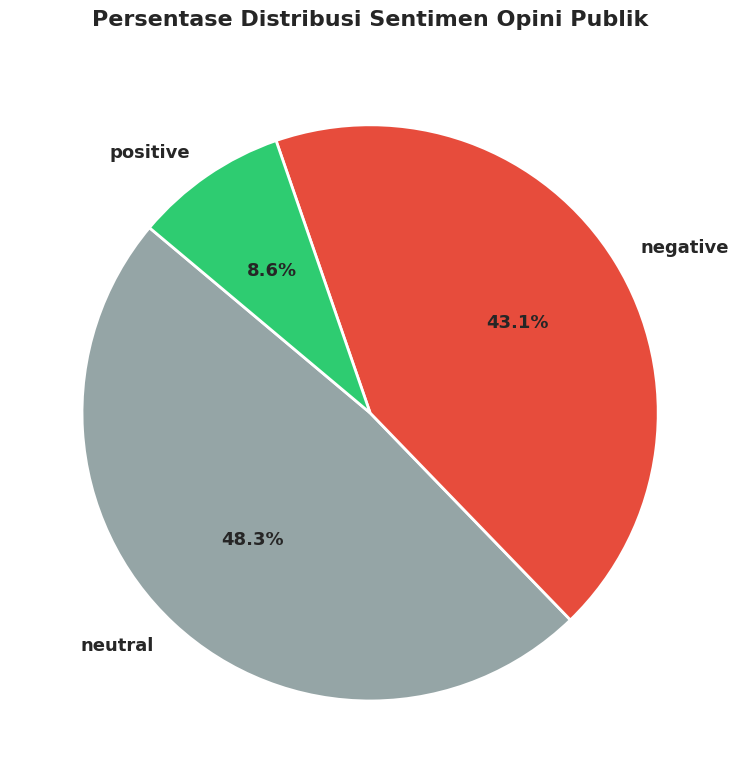

In [83]:
df['sentiment'].value_counts()
sentiment_counts = df['sentiment'].value_counts()
sns.set_theme(style="whitegrid")
palette_colors = {
    "positive": "#2ecc71",  # Hijau
    "neutral": "#95a5a6",   # Abu-abu
    "negative": "#e74c3c",  # Merah
    "unknown": "#bdc3c7"    # Abu muda (jika ada data kosong)
}

plt.figure(figsize=(8, 8))
plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',       # Menampilkan persentase dengan 1 angka di belakang koma
    startangle=140,          # Memutar sudut chart agar proporsional
    colors=[palette_colors.get(x, "#34495e") for x in sentiment_counts.index], # Ambil warna sesuai label
    textprops={'fontsize': 13, 'fontweight': 'bold'}, # Mengatur font teks persentase
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}  # Memberi garis pembatas putih antar potongan
)
plt.title('Persentase Distribusi Sentimen Opini Publik', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

##WordCloud Positive

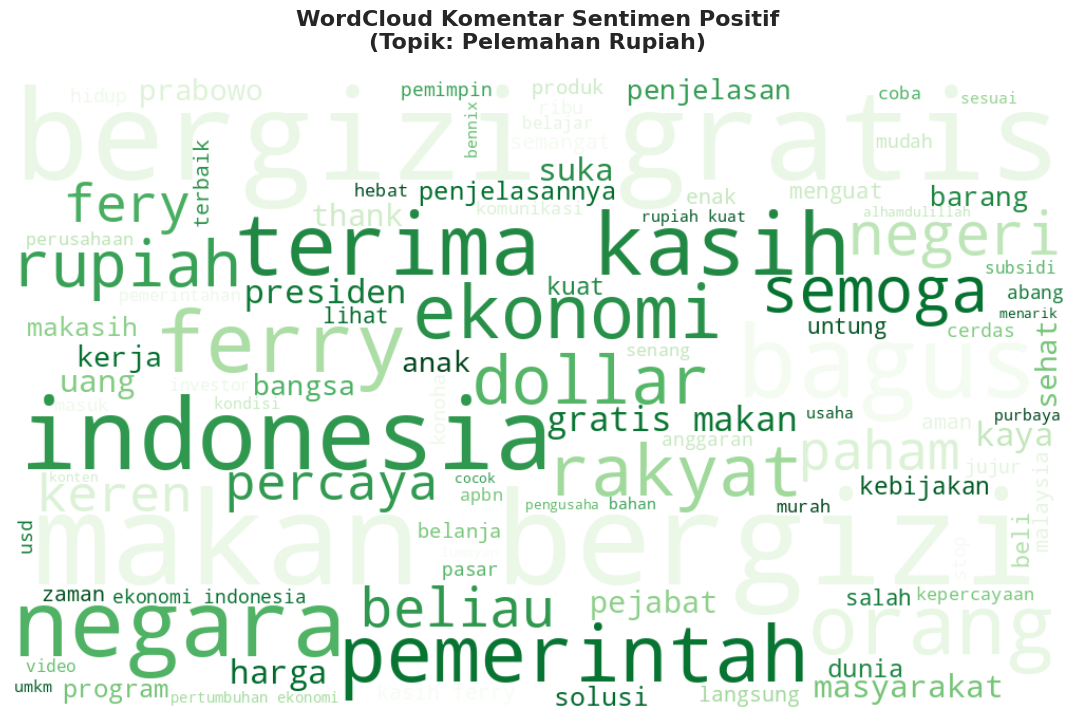

In [84]:
from wordcloud import WordCloud

df_positif = df[df['sentiment'] == 'positive']
teks_positif = ' '.join(
    [
        ' '.join(tokens) if isinstance(tokens, list) else str(tokens)
        for tokens in df_positif['stopword']
    ]
)
wordcloud_pos = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    colormap='Greens',  # Tema warna hijau untuk merepresentasikan hal positif
    max_words=100,  # Batasi hanya 100 kata paling dominan agar tidak terlalu penuh
    min_font_size=10,
    random_state=42,  # Mengunci posisi kata agar tidak berubah-ubah saat di-run ulang
).generate(teks_positif)

plt.figure(figsize=(12, 7))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')  # Menghilangkan sumbu koordinat (angka tepi grafik)
plt.title(
    'WordCloud Komentar Sentimen Positif\n(Topik: Pelemahan Rupiah)',
    fontsize=16,
    fontweight='bold',
    pad=20,
)
plt.tight_layout(pad=0)
plt.show()

##WordCloud Negative

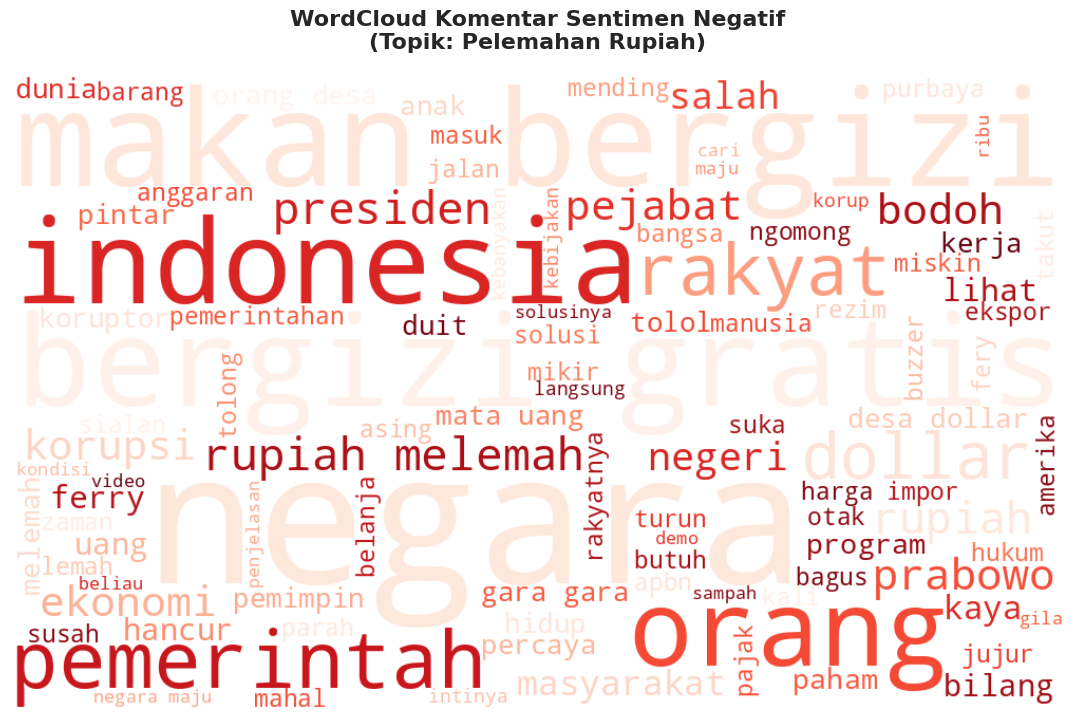

In [85]:
df_negatif = df[df['sentiment'] == 'negative']
teks_negatif = ' '.join(
    [
        ' '.join(tokens) if isinstance(tokens, list) else str(tokens)
        for tokens in df_negatif['stopword']
    ]
)
wordcloud_neg = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    colormap='Reds',  # UBAH WARNA: Menggunakan gradasi merah untuk nuansa negatif
    max_words=100,
    min_font_size=10,
    random_state=42,
).generate(teks_negatif)

plt.figure(figsize=(12, 7))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title(
    'WordCloud Komentar Sentimen Negatif\n(Topik: Pelemahan Rupiah)',
    fontsize=16,
    fontweight='bold',
    pad=20,
)
plt.tight_layout(pad=0)
plt.show()

##Top Frequent Words

/tmp/ipykernel_1347/3634577919.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


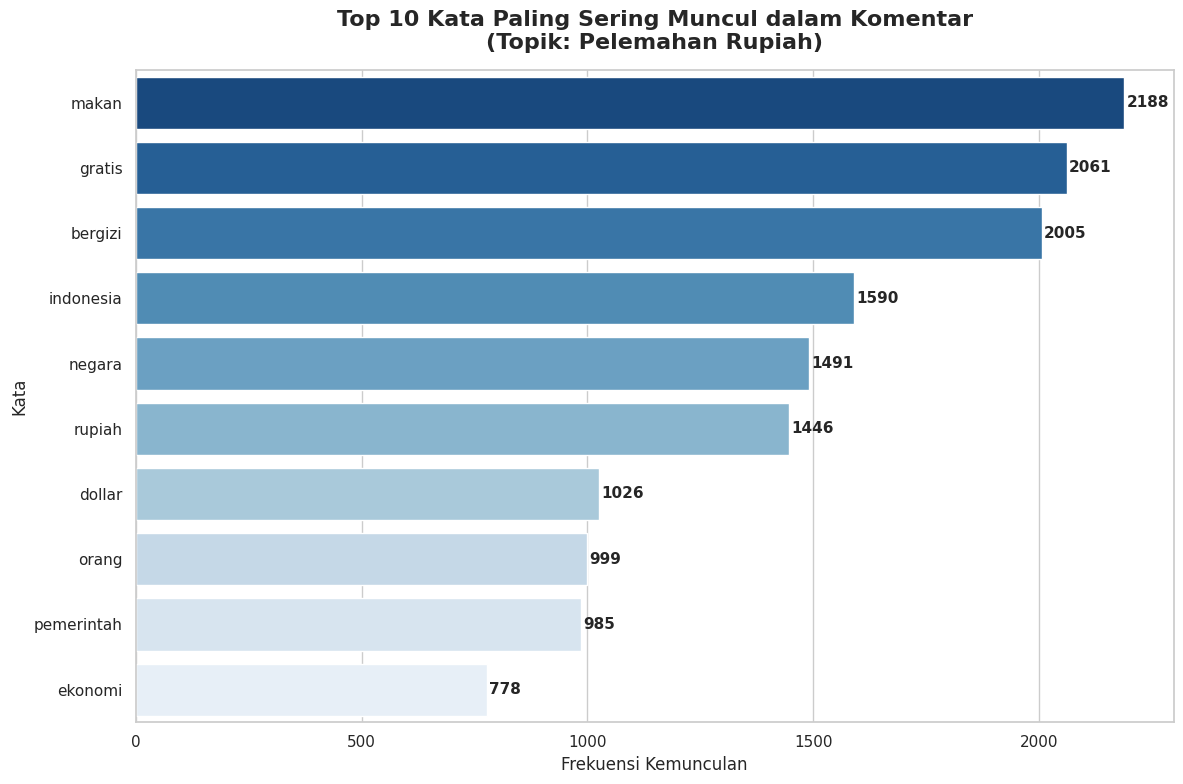

In [86]:
import seaborn as sns
from collections import Counter

all_words = []
for tokens in df['stopword']:
    if isinstance(tokens, list):
        all_words.extend(tokens)
    elif pd.notnull(tokens):
        all_words.extend(str(tokens).split())
word_counts = Counter(all_words)
top_10_words = word_counts.most_common(10)
df_top_words = pd.DataFrame(top_10_words, columns=['Kata', 'Frekuensi'])

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
sns.barplot(
    x='Frekuensi',
    y='Kata',
    data=df_top_words,
    palette='Blues_r'  # Gradasi warna biru dari gelap ke terang
)
for index, value in enumerate(df_top_words['Frekuensi']):
    plt.text(value + 5, index, str(value), va='center', fontweight='bold', fontsize=11)

plt.title('Top 10 Kata Paling Sering Muncul dalam Komentar\n(Topik: Pelemahan Rupiah)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Frekuensi Kemunculan', fontsize=12)
plt.ylabel('Kata', fontsize=12)
plt.tight_layout()
plt.show()

##Bigram

/tmp/ipykernel_1347/1197810335.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Frasa', data=df_bigram, palette='Oranges_r')


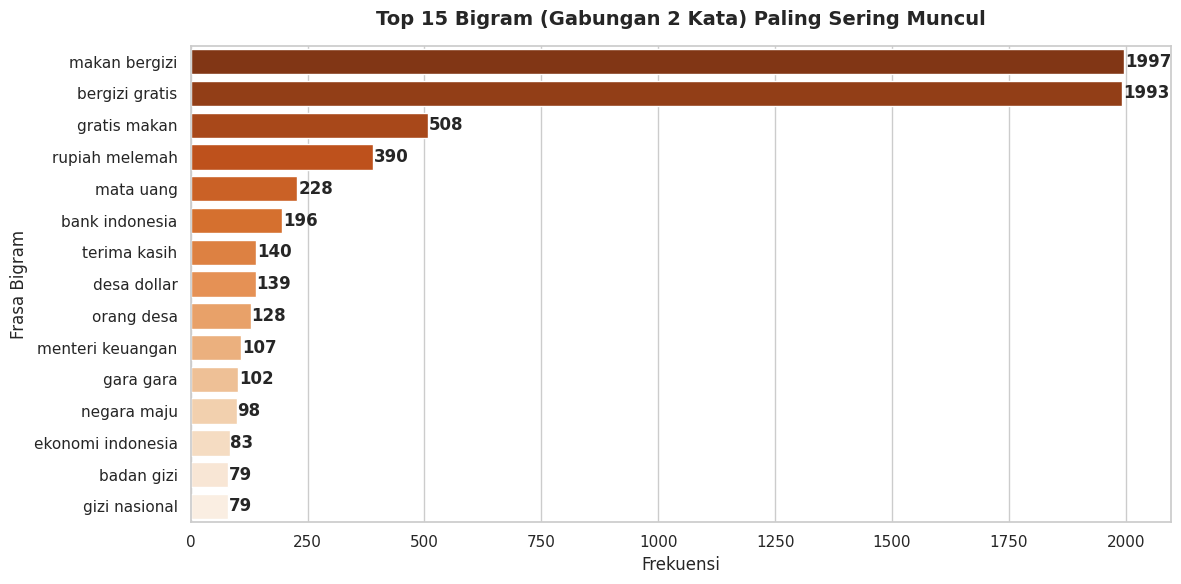

In [87]:
from nltk.util import ngrams

all_words = []
for tokens in df['stopword']:
    if isinstance(tokens, list):
        all_words.extend(tokens)
bi_grams = list(ngrams(all_words, 2))
bigram_counts = Counter(bi_grams)
top_15_bigrams = bigram_counts.most_common(15)
df_bigram = pd.DataFrame([
    {'Frasa': ' '.join(ngram), 'Frekuensi': count}
    for ngram, count in top_15_bigrams
])

plt.figure(figsize=(12, 6))
sns.barplot(x='Frekuensi', y='Frasa', data=df_bigram, palette='Oranges_r')
for index, value in enumerate(df_bigram['Frekuensi']):
    plt.text(value + 2, index, str(value), va='center', fontweight='bold')
plt.title('Top 15 Bigram (Gabungan 2 Kata) Paling Sering Muncul', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frekuensi')
plt.ylabel('Frasa Bigram')
plt.tight_layout()
plt.show()

##Trigram

/tmp/ipykernel_1347/482689895.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Frasa', data=df_trigram, palette='Purples_r')


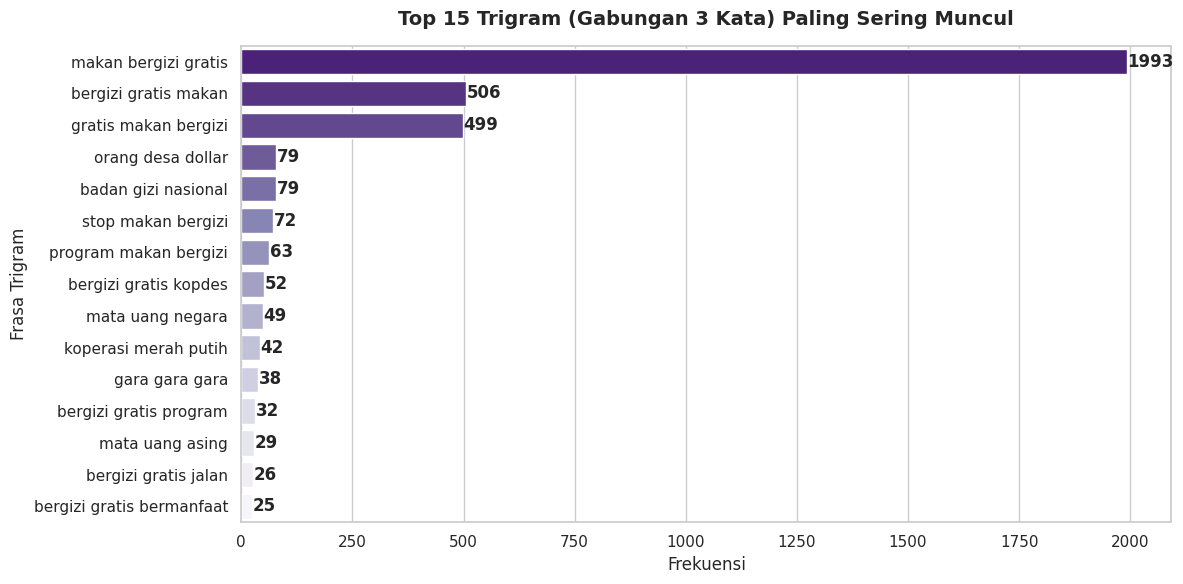

In [88]:
tri_grams = list(ngrams(all_words, 3))
trigram_counts = Counter(tri_grams)
top_15_trigrams = trigram_counts.most_common(15)
df_trigram = pd.DataFrame([
    {'Frasa': ' '.join(ngram), 'Frekuensi': count}
    for ngram, count in top_15_trigrams
])

plt.figure(figsize=(12, 6))
sns.barplot(x='Frekuensi', y='Frasa', data=df_trigram, palette='Purples_r')
for index, value in enumerate(df_trigram['Frekuensi']):
    plt.text(value + 1, index, str(value), va='center', fontweight='bold')
plt.title('Top 15 Trigram (Gabungan 3 Kata) Paling Sering Muncul', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frekuensi')
plt.ylabel('Frasa Trigram')
plt.tight_layout()
plt.show()

#Split Data

In [89]:
train_data, test_data, train_labels, test_labels = train_test_split(
    df['stemming'], df['sentiment'], test_size=0.2, random_state=42
)

#Feature Engineering

In [90]:
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_data)
X_test = vectorizer.transform(test_data)

#Model Naive Bayes

In [91]:
nb = MultinomialNB()
nb.fit(X_train, train_labels)
pred_nb = nb.predict(X_test)

#Model Decision Tree

In [92]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, train_labels)
pred_dt = dt.predict(X_test)

#Model Random Forest

In [93]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, train_labels)
pred_rf = rf.predict(X_test)

#Model Adaboost

In [94]:
adaboost = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
adaboost.fit(X_train, train_labels)
pred_adaboost = adaboost.predict(X_test)

#Model Logistic Regresi

In [95]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, train_labels)
pred_lr = lr.predict(X_test)

#Model KNN

In [96]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, train_labels)
pred_knn = knn.predict(X_test)

##Evaluasi Model

In [97]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

predictions_dict = {
    "Logistic Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "AdaBoost": pred_adaboost,
    "KNN": pred_knn,
    "Naive Bayes": pred_nb
}
results = []
daftar_sentimen = sorted(list(set(test_labels)))

for name, pred in predictions_dict.items():
    acc_global = accuracy_score(test_labels, pred)
    prec_global = precision_score(test_labels, pred, average='macro')
    rec_global = recall_score(test_labels, pred, average='macro')
    f1_global = f1_score(test_labels, pred, average='macro')
    for sentimen in daftar_sentimen:
        y_true_bin = [1 if label == sentimen else 0 for label in test_labels]
        y_pred_bin = [1 if label == sentimen else 0 for label in pred]
        tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()
        results.append({
            "Model": name,
            "Sentimen": sentimen,
            "TP": int(tp),
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "Accuracy": acc_global,
            "Precision": prec_global,
            "Recall": rec_global,
            "F1 Score": f1_global
        })
master_df = pd.DataFrame(results)

for sentimen in daftar_sentimen:
    print("\n" + "="*20 + f" TABEL EVALUASI: SENTIMEN {sentimen.upper()} " + "="*20)
    sub_df = master_df[master_df['Sentimen'] == sentimen].copy()
    sub_df = sub_df.drop(columns=['Sentimen'])
    sub_df = sub_df.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
    display(sub_df.round(3))


==================== TABEL EVALUASI: SENTIMEN NEGATIVE ====================


,Model,TP,TN,FP,FN,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,581,846,184,258,0.717,0.692,0.624,0.647
1,Random Forest,502,860,170,337,0.673,0.635,0.592,0.605
2,Naive Bayes,597,762,268,242,0.685,0.708,0.559,0.585
3,Decision Tree,480,789,241,359,0.624,0.575,0.564,0.567
4,KNN,220,932,98,619,0.547,0.551,0.459,0.449
5,AdaBoost,208,910,120,631,0.537,0.583,0.390,0.351



==================== TABEL EVALUASI: SENTIMEN NEUTRAL ====================


,Model,TP,TN,FP,FN,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,701,681,310,177,0.717,0.692,0.624,0.647
1,Random Forest,698,605,386,180,0.673,0.635,0.592,0.605
2,Naive Bayes,650,682,309,228,0.685,0.708,0.559,0.585
3,Decision Tree,625,609,382,253,0.624,0.575,0.564,0.567
4,KNN,766,290,701,112,0.547,0.551,0.459,0.449
5,AdaBoost,793,248,743,85,0.537,0.583,0.390,0.351



==================== TABEL EVALUASI: SENTIMEN POSITIVE ====================


,Model,TP,TN,FP,FN,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,58,1682,35,94,0.717,0.692,0.624,0.647
1,Random Forest,58,1662,55,94,0.673,0.635,0.592,0.605
2,Naive Bayes,34,1706,11,118,0.685,0.708,0.559,0.585
3,Decision Tree,62,1638,79,90,0.624,0.575,0.564,0.567
4,KNN,37,1670,47,115,0.547,0.551,0.459,0.449
5,AdaBoost,3,1715,2,149,0.537,0.583,0.390,0.351


#Download Model ML

In [98]:
import pickle

# 1. Simpan Model Logistic Regression (lr)
with open('model_sentimen.pkl', 'wb') as f:
    pickle.dump(lr, f)

# 2. Simpan Count Vectorizer (vectorizer)
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)